In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)

In [3]:
X=2*np.random.rand(100,1)

In [4]:
y = 4 +3*X+1.5*X**2+np.random.randn(100, 1)

In [5]:

from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.preprocessing import PolynomialFeatures

In [21]:
degree=2
poly=PolynomialFeatures(degree=2,include_bias=True)


In [22]:
poly_train=poly.fit_transform(X_train)

In [23]:
poly_train

array([[1.00000000e+00, 1.06725090e-01, 1.13902449e-02],
       [1.00000000e+00, 1.32688300e+00, 1.76061848e+00],
       [1.00000000e+00, 1.70088423e-01, 2.89300716e-02],
       [1.00000000e+00, 5.60887984e-01, 3.14595331e-01],
       [1.00000000e+00, 1.17311008e+00, 1.37618726e+00],
       [1.00000000e+00, 1.34093502e+00, 1.79810673e+00],
       [1.00000000e+00, 1.97772218e+00, 3.91138501e+00],
       [1.00000000e+00, 1.80675904e+00, 3.26437823e+00],
       [1.00000000e+00, 1.07763347e+00, 1.16129389e+00],
       [1.00000000e+00, 2.78552695e-01, 7.75916036e-02],
       [1.00000000e+00, 1.37043900e+00, 1.87810305e+00],
       [1.00000000e+00, 5.87228297e-01, 3.44837073e-01],
       [1.00000000e+00, 1.79177244e+00, 3.21044846e+00],
       [1.00000000e+00, 3.39660839e-01, 1.15369486e-01],
       [1.00000000e+00, 1.15677923e+00, 1.33813818e+00],
       [1.00000000e+00, 1.84677190e-01, 3.41056643e-02],
       [1.00000000e+00, 1.32758929e+00, 1.76249332e+00],
       [1.00000000e+00, 1.07179

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
poly_regression=LinearRegression()

In [26]:
poly_regression.fit(poly_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[0. ,2.34,1.72]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[4.5]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[11.83, 1.26, 0. ]"


In [27]:
poly_regression.coef_

array([[0.        , 2.33915935, 1.71782948]])

In [28]:
poly_regression.intercept_

array([4.49951103])

In [30]:
y_poly_predict=poly_regression.predict(poly_train)

In [31]:
from sklearn.metrics import mean_squared_error

In [32]:
mse_train = mean_squared_error(y_train, y_poly_predict)
print(f'Mean Squared Error on Training Data: {mse_train}')

Mean Squared Error on Training Data: 0.8207003507057354


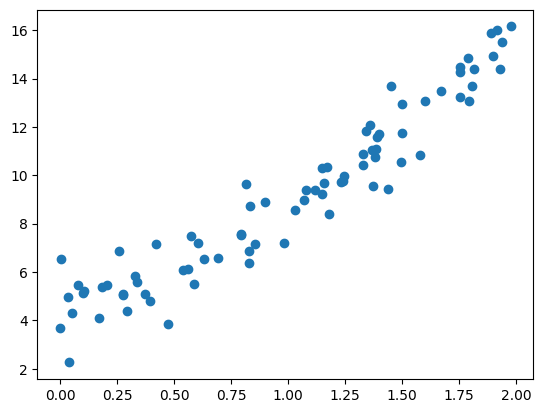

In [35]:
plt.scatter(X_train, y_train, label = "training data")

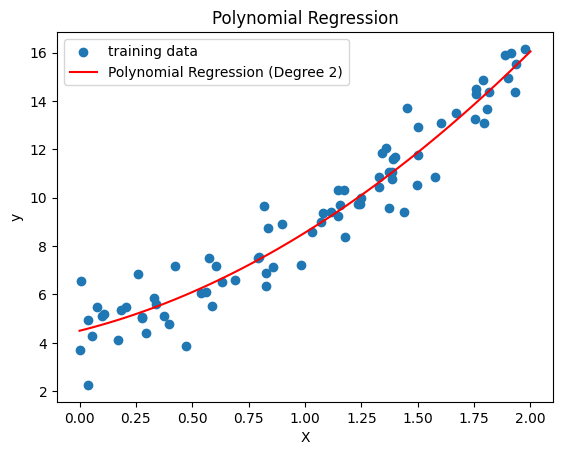

In [38]:
plt.scatter(X_train, y_train, label = "training data")
X_range = np.linspace(0, 2, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
plt.plot(X_range, poly_regression.predict(X_range_poly), color='red', label=f'Polynomial Regression (Degree {degree})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.legend()
plt.show()